In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri
import pandas as pd
import rasterio
from collections import Counter,defaultdict
from matplotlib.path import Path
import matplotlib.patches as mpatches
import MFO
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
print("环境创建成功！")

环境创建成功！


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


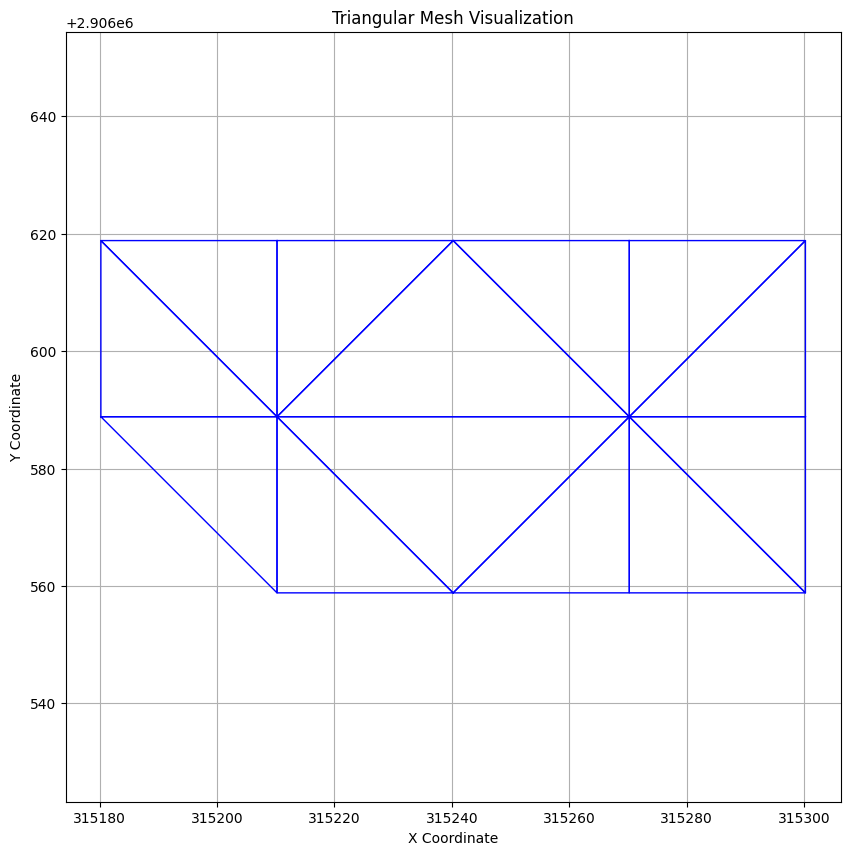

In [3]:
# 读取数据
file_path = "RKCP栅格数据/转表/实验三角网.csv"
df = pd.read_csv(file_path)

# 按 Tri_Index 进行分组
triangles = df.groupby("Tri_Index")

# 创建绘图
plt.figure(figsize=(10, 10))
for _, group in triangles:
    # 获取当前三角形的顶点坐标
    x = group["x"].tolist()
    y = group["y"].tolist()
    
    # 连接三角形的三个点并回到起点
    x.append(x[0])
    y.append(y[0])
    
    # 画出三角形
    plt.plot(x, y, 'b-', linewidth=1)
# 定义点的坐标
# points = [
#     (315210.2235, 2906588.825),(315209.32616573,2906613.92412379),( 315221.87206853,2906582.31748848),(315189.2845395,2906589.29033641)
# ]

# 提取x和y坐标
# x_coords = [point[0] for point in points]
# y_coords = [point[1] for point in points]

# # 绘制点
# plt.scatter(x_coords, y_coords, color='blue', s=50, label='Points')
# 设置图形参数
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Triangular Mesh Visualization")
plt.axis("equal")  # 保持比例
plt.grid(True)

# 显示图形
plt.show()


In [105]:
class TriangularMesh:
    """用于存储三角网数据并提供查询功能"""
    def __init__(self, file_path):
        self.triangles = {}  # 存储三角形信息
        self.vertex_index = {}  # 存储顶点编号（每个顶点都有一个索引）
        self.adjacency = defaultdict(set)  # 存储每个顶点的邻接点
        self.boundary_points = set()  # 存储边界点

        # 读取数据
        df = pd.read_csv(file_path)
        
        # 为每个三角形添加顶点编号，并记录邻接点
        for tri_index, group in df.groupby("Tri_Index"):
            if len(group) == 3:  # 确保数据正确
                vertices = list(zip(group["x"], group["y"]))
                ls_value = group["LS"].iloc[0]  # LS 值
                self.triangles[tri_index] = (vertices, ls_value)
                
                # 为每个顶点添加编号索引
                for i, vertex in enumerate(vertices):
                    if vertex not in self.vertex_index:
                        self.vertex_index[vertex] = len(self.vertex_index)
                    
                    # 更新顶点的邻接点（即三角形的其他两个顶点）
                    for j in range(3):
                        if vertices[j] != vertex:
                            self.adjacency[vertex].add(vertices[j])
                            
        # 计算并存储边界点
        self._compute_boundary_points()

    def _compute_boundary_points(self):
        """提前计算并存储三角网中的边界点"""
        # 统计所有边的出现次数
        edges_count = Counter()

        # 遍历所有三角形
        for vertices, _ in self.triangles.values():
            # 对每个三角形的三条边进行计数
            for i in range(3):
                edge = tuple(sorted([vertices[i], vertices[(i + 1) % 3]]))
                edges_count[edge] += 1

        # 边界边：出现次数为 1 的边
        for edge, count in edges_count.items():
            if count == 1:  # 这是一个边界边
                self.boundary_points.update(edge)  # 将这两个端点加入边界点集合

    def get_triangle(self, tri_index):
        """根据 Tri_Index 查询三角形顶点和 LS"""
        return self.triangles.get(tri_index, None)
    
    def get_adjacent_vertices(self, vertex):
        """获取与指定顶点相连的邻接点"""
        return self.adjacency.get(vertex, set())
    
    def get_boundary_points(self):
        """返回预计算的边界点"""
        return self.boundary_points
    
    def get_triangles_by_vertex(self, vertex):
        """根据指定顶点查询所有与之拓扑关联的三角形的 Tri_Index"""
        associated_triangles = []
        for tri_index, (vertices, _) in self.triangles.items():
            if vertex in vertices:
                associated_triangles.append(tri_index)
        return associated_triangles
    
#     def find_boundary_points(self):
#         """找出三角网中的边界点"""
#         # 统计所有边的出现次数
#         edges_count = Counter()

#         # 遍历所有三角形
#         for vertices, _ in self.triangles.values():
#             # 对每个三角形的三条边进行计数
#             for i in range(3):
#                 edge = tuple(sorted([vertices[i], vertices[(i + 1) % 3]]))
#                 edges_count[edge] += 1

#         # 边界边：出现次数为 1 的边
#         boundary_points = set()
#         for edge, count in edges_count.items():
#             if count == 1:  # 这是一个边界边
#                 boundary_points.update(edge)  # 将这两个端点加入边界点集合

#         return boundary_points

def compute_subcentroids(triangle):
    """计算单个三角形的三个小三角形的重心"""
    if triangle is None:
        raise ValueError("错误：该 Tri_Index 不存在！")

    vertices, _ = triangle  # 解包三角形信息

    # 计算原三角形的重心
    centroid_main = tuple(sum(coord) / 3 for coord in zip(*vertices))

    # 计算三个小三角形的重心
    subcentroids = [
        tuple(sum(coord) / 3 for coord in zip(vertices[0], vertices[1], centroid_main)),
        tuple(sum(coord) / 3 for coord in zip(vertices[1], vertices[2], centroid_main)),
        tuple(sum(coord) / 3 for coord in zip(vertices[2], vertices[0], centroid_main))
    ]
    
    return subcentroids

# **排序角度法：确保邻接点能正确构成多边形**
def sort_adjacent_vertices(vertex, neighbors):
    """
    按角度对邻接点进行排序，确保它们按顺序形成多边形
    :param vertex: (x, y) 需要排序邻接点的基准点
    :param neighbors: [(x1, y1), (x2, y2), ...] 该点的所有邻接点
    :return: 排序后的邻接点列表
    """
    if len(neighbors) < 3:
        return None  # 不能形成多边形
    
    x0, y0 = vertex  # 参考点
    angles = [(np.arctan2(y - y0, x - x0), (x, y)) for x, y in neighbors]
    sorted_neighbors = [point for _, point in sorted(angles)]
    
    return sorted_neighbors


# **叉积法判断是否为凸多边形**
def is_convex_polygon(vertex, sorted_neighbors):
    """
    通过叉积法判断邻接点组成的多边形是否为凸多边形
    :param vertex: (x, y) 需要检查的基准点
    :param sorted_neighbors: 排序后的邻接点列表
    :return: True（凸多边形）或 False（凹多边形）
    """
    if sorted_neighbors is None:
        return False
    
    n = len(sorted_neighbors)
    sign = None

    for i in range(n):
        x1, y1 = sorted_neighbors[i]
        x2, y2 = sorted_neighbors[(i + 1) % n]

        dx1, dy1 = x1 - vertex[0], y1 - vertex[1]
        dx2, dy2 = x2 - vertex[0], y2 - vertex[1]

        cross_product = dx1 * dy2 - dy1 * dx2

        if sign is None:
            sign = np.sign(cross_product)
        elif sign != np.sign(cross_product):
            return False  # 叉积方向不一致，说明是凹多边形
    
    return True

def select_movable_vertex(tri_index, mesh):
    """在指定的三角形中选择一个可以移动的点"""
    vertices, _ = mesh.get_triangle(tri_index)
    if not vertices:
        raise ValueError(f"三角形 {tri_index} 不存在！")

    boundary_points = mesh.get_boundary_points()
    min_neighbors = float('inf')  # 初始值为无穷大
    selected_vertex = None

    # 遍历三角形的三个顶点，找到符合条件的顶点
    for vertex in vertices:
        if vertex in boundary_points:
            continue  # 跳过边界点

        neighbors = mesh.get_adjacent_vertices(vertex)
        if len(neighbors) < 3:
            continue  # 不能形成多边形

        # 先检查邻接点构成的多边形是否为凸多边形
        sorted_neighbors = sort_adjacent_vertices(vertex, neighbors)
        if is_convex_polygon(vertex, sorted_neighbors):
            # 选择邻接点最少的顶点
            if len(neighbors) < min_neighbors:
                min_neighbors = len(neighbors)
                selected_vertex = vertex

    return selected_vertex  # 返回符合条件的顶点，如果没有则为 None   
#     # 遍历三角形的三个顶点，找到符合条件的顶点
#     for vertex in vertices:
#         if vertex in boundary_points:
#             continue  # 跳过边界点

#         neighbors = mesh.get_adjacent_vertices(vertex)
#         if len(neighbors) < 3:
#             continue  # 不能形成多边形

#         # 先检查邻接点构成的多边形是否为凸多边形
#         sorted_neighbors = sort_adjacent_vertices(vertex, neighbors)
#         if is_convex_polygon(vertex, sorted_neighbors):
#             return vertex  # 找到符合条件的点

#     return None  # 没有找到合适的顶点

# def get_raster_value_at_points(src, points):
#     """获取多个点的栅格值"""
#     raster_values = []
#     width, height = src.width, src.height  # 栅格宽高
#     nodata_value = src.nodata  # 获取无数据值
    
#     for x, y in points:
#         row, col = src.index(x, y)  # 转换为栅格坐标
#         if 0 <= row < height and 0 <= col < width:
#             value = src.read(1)[row, col]  # 获取栅格值
#             if value == nodata_value:
#                 value = None
#             raster_values.append(value)
#         else:
#             raster_values.append(None)
    
#     return raster_values

def get_raster_value_at_points(raster, transform, points):
    """获取多个点的栅格值"""
    raster_values = []
    width, height = raster.shape  # 获取栅格数据的宽高
    nodata_value = None  # 如果有无数据值，可以指定
    
    for x, y in points:
        col, row = ~transform * (x, y)  # 使用仿射变换转换为栅格坐标
        row, col = int(row), int(col)  # 将坐标转换为整数
        
        if 0 <= row < height and 0 <= col < width:
            value = raster[row, col]  # 获取栅格值
            if value == nodata_value:
                value = None
            raster_values.append(value)
        else:
            raster_values.append(None)
    
    return raster_values


def get_class_from_A(A):
    """根据A值返回class值"""
    if A < 500:
        return 1
    elif 500 <= A < 2500:
        return 2
    elif 2500 <= A < 5000:
        return 3
    elif 5000 <= A < 8000:
        return 4
    elif 8000 <= A < 15000:
        return 5
    else:
        return 6

def get_lbub(points):
    """
    找到给定点列表的最小和最大坐标。

    参数:
        points (list of tuples): 点的坐标列表，每个点是一个包含两个元素的元组 (x, y)。

    返回:
        tuple: 包含两个元组，第一个元组是 [x_min, y_min]，第二个元组是 [x_max, y_max]。
    """
    # 提取所有 x 坐标和 y 坐标
    x_coords = [point[0] for point in points]
    y_coords = [point[1] for point in points]

    # 找到最小和最大 x 坐标
    x_min = min(x_coords)
    x_max = max(x_coords)

    # 找到最小和最大 y 坐标
    y_min = min(y_coords)
    y_max = max(y_coords)

    # 返回结果
    return (x_min, y_min), (x_max, y_max)

In [106]:
# **使用示例**
file_path = "RKCP栅格数据/转表/实验三角网.csv"
raster_path = "RKCP栅格数据/RKCP.tif"
# 创建三角网对象
mesh = TriangularMesh(file_path)
# **读取 RKCP 栅格文件**
with rasterio.open(raster_path) as src:
    raster = src.read(1)  # 读取第一波段数据
    transform = src.transform  # 获取仿射变换
    width, height = src.width, src.height  # 栅格宽高
    nodata_value = src.nodata  # 获取无数据值

# 查询一个三角形
tri_index = 23745
triangle_data = mesh.get_triangle(tri_index)
triangle_data


([(315240.2235, 2906558.825),
  (315270.2235, 2906588.825),
  (315270.2235, 2906558.825)],
 1.48010575)

In [107]:
subcentroids = compute_subcentroids(triangle_data)
print("三个小三角形的重心坐标：", subcentroids)


三个小三角形的重心坐标： [(315256.89016666665, 2906572.1583333337), (315266.89016666665, 2906572.1583333337), (315256.89016666665, 2906562.1583333337)]


In [108]:
# boundary_points = mesh.find_boundary_points()
boundary_points = mesh.get_boundary_points()
print("边界点列表:", boundary_points)

边界点列表: {(315210.2235, 2906618.825), (315180.2235, 2906588.825), (315270.2235, 2906558.825), (315300.2235, 2906588.825), (315240.2235, 2906558.825), (315300.2235, 2906558.825), (315270.2235, 2906618.825), (315210.2235, 2906558.825), (315180.2235, 2906618.825), (315240.2235, 2906618.825), (315300.2235, 2906618.825)}


In [109]:
vertex_to_move = (315270.2235, 2906588.825)  # 假设要查询邻接点的点
adjacent_vertices = mesh.get_adjacent_vertices(vertex_to_move)
print(f"顶点 {vertex_to_move} 的邻接点: {adjacent_vertices}")
adjacent_vertices

顶点 (315270.2235, 2906588.825) 的邻接点: {(315270.2235, 2906558.825), (315300.2235, 2906588.825), (315240.2235, 2906558.825), (315300.2235, 2906558.825), (315210.2235, 2906588.825), (315270.2235, 2906618.825), (315240.2235, 2906618.825), (315300.2235, 2906618.825)}


{(315210.2235, 2906588.825),
 (315240.2235, 2906558.825),
 (315240.2235, 2906618.825),
 (315270.2235, 2906558.825),
 (315270.2235, 2906618.825),
 (315300.2235, 2906558.825),
 (315300.2235, 2906588.825),
 (315300.2235, 2906618.825)}

In [110]:
# **主代码**
# 查询一个三角形
tri_index = 23745
triangle_data = mesh.get_triangle(tri_index)
subcentroids = compute_subcentroids(triangle_data)

# **获取与移动节点相关的三角形及其重心**
movable_vertex = select_movable_vertex(tri_index, mesh)
if movable_vertex:
    associated_triangles = mesh.get_triangles_by_vertex(movable_vertex)
    print(f"选择移动的节点: {movable_vertex}")
    
    all_subcentroids = {}
    for tri_idx in associated_triangles:
        triangle_data = mesh.get_triangle(tri_idx)
        subcentroids = compute_subcentroids(triangle_data)
        all_subcentroids[tri_idx] = subcentroids  # 将重心与三角形ID关联

    print(f"相关三角形的所有重心坐标：{all_subcentroids}")
    
    # **获取每个重心点的栅格值，并计算A和class**
    tri_class_values = {}  # 用来存储每个三角形的class值列表
    for tri_idx, subcentroids in all_subcentroids.items():
        # 获取三个重心点的栅格值
        raster_values = get_raster_value_at_points(raster, transform, subcentroids)
        
        # 获取该三角形的LS值
        _, ls_value = mesh.get_triangle(tri_idx)
        
        # 存储该三角形每个重心的class值
        class_values = []
        for i, value in enumerate(raster_values):
            if value is not None:
                A = value * ls_value
                class_value = get_class_from_A(A)
                class_values.append(class_value)  # 添加到列表中
                print(f"三角形 {tri_idx} 的重心 {i+1}，栅格值：{value}, LS：{ls_value}, A：{A}, class：{class_value}")
        
        # 将class值列表存储到字典中
        tri_class_values[tri_idx] = class_values
    
    print(f"每个三角形的三个重心的class值：{tri_class_values}")

    # **计算每个三角形的唯一class值的个数**
    unique_class_counts = {tri_idx: len(set(class_values)) for tri_idx, class_values in tri_class_values.items()}
    print(f"每个三角形的唯一class值数量：{unique_class_counts}")
else:
    print("没有符合条件的移动顶点")

选择移动的节点: (315270.2235, 2906588.825)
相关三角形的所有重心坐标：{195: [(315240.2235, 2906592.1583333337), (315230.2235, 2906602.1583333337), (315250.2235, 2906602.1583333337)], 3850: [(315296.89016666665, 2906575.491666667), (315286.89016666665, 2906575.491666667), (315286.89016666665, 2906585.491666667)], 3858: [(315240.2235, 2906585.491666667), (315250.2235, 2906575.491666667), (315230.2235, 2906575.491666667)], 9877: [(315283.55683333334, 2906615.491666667), (315283.55683333334, 2906605.491666667), (315273.55683333334, 2906605.491666667)], 9888: [(315283.55683333334, 2906572.1583333337), (315283.55683333334, 2906562.1583333337), (315273.55683333334, 2906572.1583333337)], 9889: [(315286.89016666665, 2906602.1583333337), (315296.89016666665, 2906602.1583333337), (315286.89016666665, 2906592.1583333337)], 23699: [(315256.89016666665, 2906605.491666667), (315256.89016666665, 2906615.491666667), (315266.89016666665, 2906605.491666667)], 23745: [(315256.89016666665, 2906572.1583333337), (315266.89016666

In [112]:
update_class_counts(mesh,195)

{}

In [98]:
def optimize_vertex_position(tri_index, mesh, polygon_path, lb, ub, max_iter=100, pop=50): 
    """
    使用飞蛾扑火优化算法优化指定三角形的节点位置，使得与该节点相关联的所有三角形的
    唯一class值的个数最小
    :param tri_index: 要移动的三角形的 Tri_Index
    :param mesh: TriangularMesh 对象
    :param polygon_path: 多边形区域的 Path 对象，用于限制节点移动范围
    :param lb: 下边界 (x_min, y_min)，通过排序好的邻接点坐标列表中获取
    :param ub: 上边界 (x_max, y_max)，通过排序好的邻接点坐标列表中获取
    :param max_iter: 最大迭代次数
    :param pop: 种群数量
    :return: 优化后的节点位置
    """

    # 选择可以移动的节点
    movable_vertex = select_movable_vertex(tri_index, mesh)
    if movable_vertex is None:
        raise ValueError(f"无法选择可以移动的节点，三角形 {tri_index} 可能没有符合条件的节点。")

    # 定义适应度函数
    def fitness_function(X):
        # 移动后的节点位置
        position = (X[0], X[1])
        
        # 如果位置不在多边形内，返回一个非常大的值作为惩罚
        if not polygon_path.contains_point(position):
            return 1e10

        # 更新三角网中该节点的位置信息
        mesh.triangles[tri_index] = update_triangle_position(tri_index, mesh, movable_vertex, position)

        # 更新与移动节点相关联的所有三角形的唯一class值的个数
        unique_class_counts = update_class_counts(mesh, tri_index)
        
        # 返回唯一class值的总和作为优化目标
        return sum(unique_class_counts.values())  # 目标是最小化这个值

    # 维度为2 (x, y)
    dim = 2
    lb = np.array(lb)  # 转为 NumPy 数组
    ub = np.array(ub)

    # 调用 MFO 算法进行优化
    best_fitness, best_position = MFO.MFO(pop, dim, lb, ub, max_iter, fitness_function)

    return best_position.flatten()  # 返回优化后的节点位置


def update_triangle_position(tri_index, mesh, movable_vertex, new_position):
    """
    更新三角形中可移动节点的位置
    :param tri_index: 三角形的 Tri_Index
    :param mesh: TriangularMesh 对象
    :param movable_vertex: 被移动的节点
    :param new_position: 新的位置 (x, y)
    :return: 更新后的三角形数据
    """
    vertices, ls_value = mesh.get_triangle(tri_index)
    updated_vertices = [new_position if vertex == movable_vertex else vertex for vertex in vertices]
    
    return (updated_vertices, ls_value)


def update_class_counts(mesh, tri_index):
    """
    更新与指定三角形关联的所有三角形的唯一class值的个数
    :param mesh: TriangularMesh 对象
    :param tri_index: 指定的三角形的 Tri_Index
    :return: 唯一class值的字典
    """
    associated_triangles = mesh.get_triangles_by_vertex(tri_index)
    tri_class_values = {}  # 存储每个三角形的class值列表
    for tri_idx in associated_triangles:
        triangle_data = mesh.get_triangle(tri_idx)
        subcentroids = compute_subcentroids(triangle_data)

        class_values = []
        for subcentroid in subcentroids:
            raster_values = get_raster_value_at_points(raster, transform, [subcentroid])
            _, ls_value = mesh.get_triangle(tri_idx)
            for value in raster_values:
                if value is not None:
                    A = value * ls_value
                    class_value = get_class_from_A(A)
                    class_values.append(class_value)  # 添加到列表中
        tri_class_values[tri_idx] = class_values

    unique_class_counts = {tri_idx: len(set(class_values)) for tri_idx, class_values in tri_class_values.items()}
    return unique_class_counts

In [99]:
tri_index = 195  # 需要移动的三角形ID
initial_position = select_movable_vertex(tri_index,mesh)
neighbors = mesh.get_adjacent_vertices(initial_position)
sorted_neighbors = sort_adjacent_vertices(initial_position,neighbors)
lb,ub = get_lbub(sorted_neighbors)
sorted_neighbors.append(sorted_neighbors[0])
polygon_path = Path(sorted_neighbors)

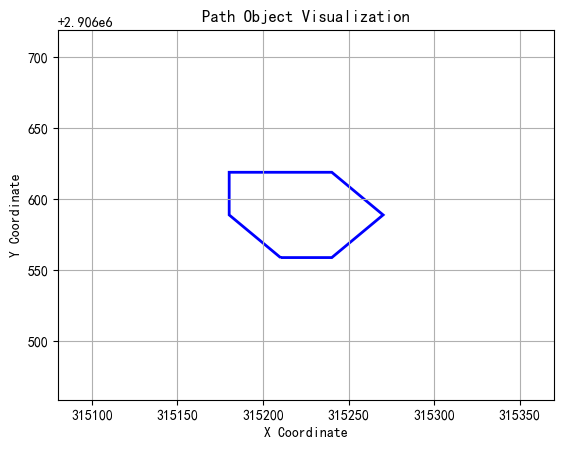

In [100]:

# 创建PathPatch对象
patch = mpatches.PathPatch(polygon_path, facecolor='none', edgecolor='blue', lw=2)

# 绘制图形
fig, ax = plt.subplots()
ax.add_patch(patch)

# 设置图形范围
ax.set_xlim(min(x for x, y in sorted_neighbors) - 100, max(x for x, y in sorted_neighbors) + 100)
ax.set_ylim(min(y for x, y in sorted_neighbors) - 100, max(y for x, y in sorted_neighbors) + 100)

# 添加标题和标签
ax.set_title('Path Object Visualization')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')

# 添加网格
ax.grid(True)

# 显示图形
plt.show()


In [101]:
optimized_position = optimize_vertex_position(tri_index, mesh, polygon_path, lb, ub)

print("优化后的节点位置：", optimized_position)

优化后的节点位置： [ 315239.85157389 2906567.92180775]
